In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pathlib import Path

%matplotlib inline
%config InlineBackend.figure_format = 'retina'


In [10]:
DATA_DIR = Path("EGU_spatial_rmse")
EXTENT       = [-17, 16, 40, 66]
EXTENT_TIGHT = [-12, 12, 45, 61]
CMAP         = "YlOrRd"

FILES = [
    ("spatial_rmse_ws100_Transformer (No Power).nc",              "ws100 | No Power"),
    ("spatial_rmse_ws100_Transformer (Vanilla Power).nc",         "ws100 | Vanilla Power"),
    ("spatial_rmse_ws100_Transformer (Vanilla Power + Synthetic).nc", "ws100 | Vanilla Power + Synthetic"),
]

all_rmse, all_lats, all_lons, all_titles = [], [], [], []
lead_times = None

for fname, title in FILES:
    ds = xr.open_dataset(DATA_DIR / fname)
    all_rmse.append(ds["rmse"].values)
    all_lats.append(ds["latitude"].values)
    all_lons.append(ds["longitude"].values)
    all_titles.append(title)
    if lead_times is None:
        lead_times = ds["lead_time"].values
    ds.close()

print(f"Lead times available: {lead_times} h")

Lead times available: [ 0  3  6  9 12 15 18 21 24 27 30 33 36] h


In [11]:
def robust_range(arrays):
    combined = np.concatenate(arrays)
    return np.nanpercentile(combined, 2), np.nanpercentile(combined, 98)

In [8]:
def robust_range(arrays):
    combined = np.concatenate(arrays)
    return np.nanpercentile(combined, 2), np.nanpercentile(combined, 98)


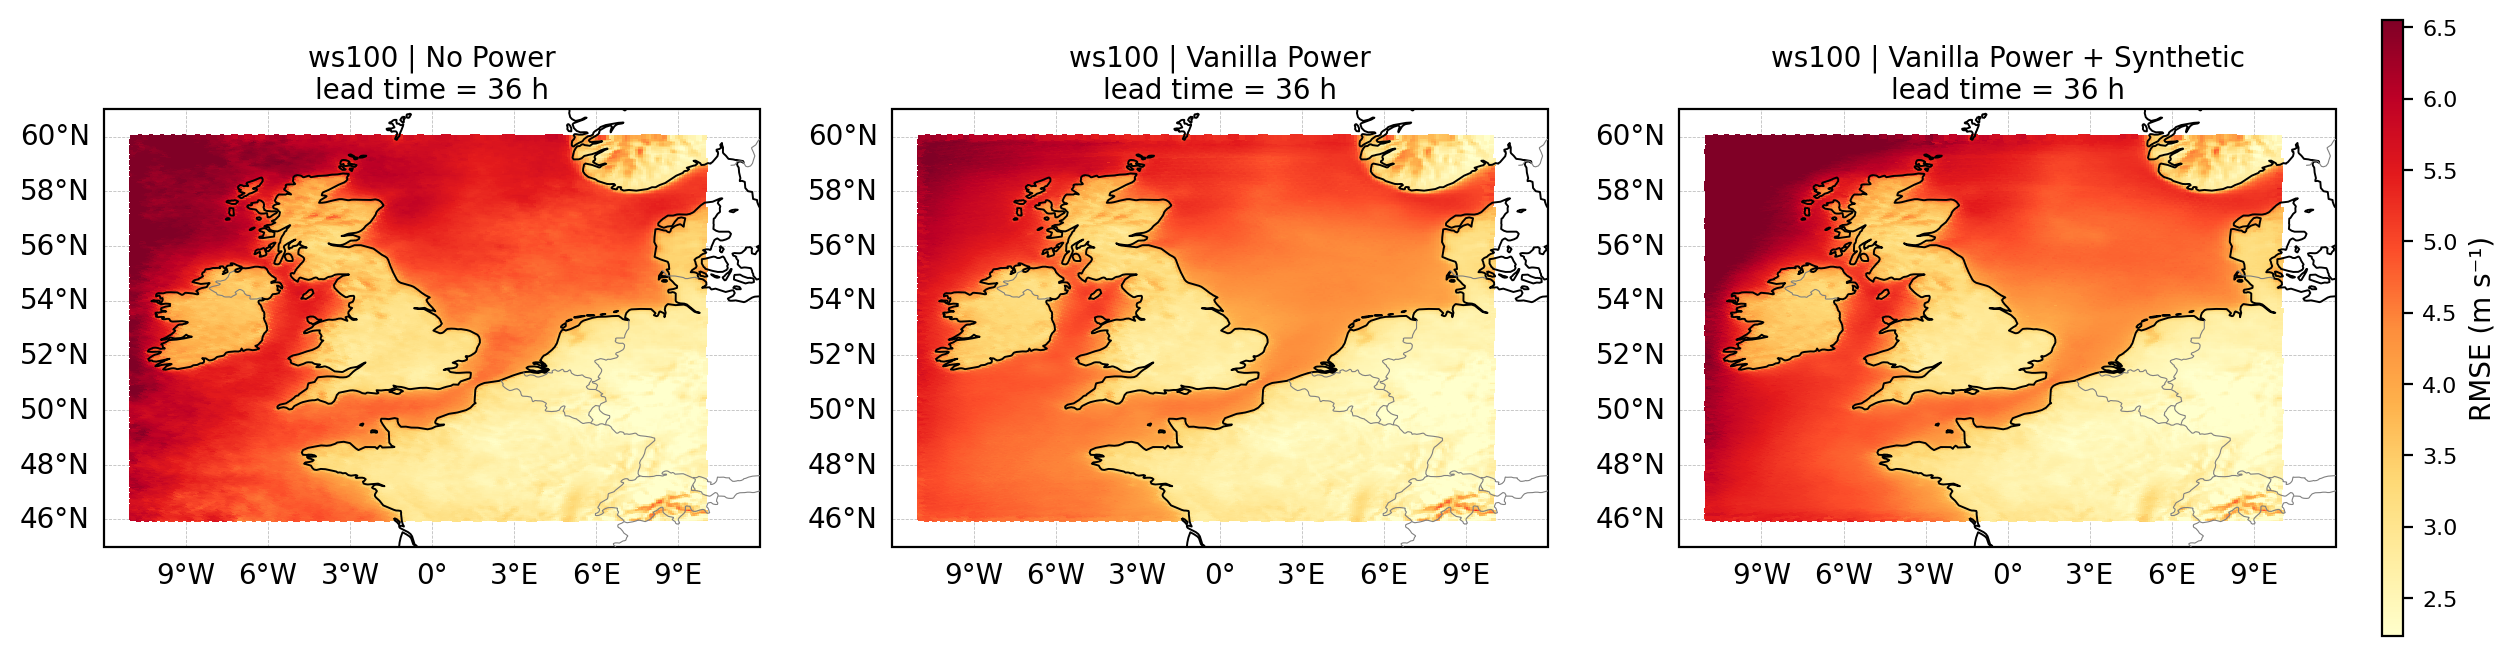

In [15]:
# ── CHOOSE HERE ──────────────────────────────────────────────────
MODE        = "leadtime"   # "mean" or "leadtime"
LEAD_TIME_H = 36            # only used when MODE = "leadtime"
# ─────────────────────────────────────────────────────────────────

# Shared colour scale across all three models
if MODE == "mean":
    fields = [r.mean(axis=0) for r in all_rmse]
else:
    lt_idx = list(lead_times).index(LEAD_TIME_H)
    fields = [r[lt_idx] for r in all_rmse]

vmin, vmax = robust_range(fields)
label = "mean over lead times (0–36 h)" if MODE == "mean" else f"lead time = {LEAD_TIME_H} h"

proj = ccrs.PlateCarree()
fig, axes = plt.subplots(1, 3, figsize=(15, 5),
                         subplot_kw={"projection": proj})

for ax, field, title, lats, lons in zip(axes, fields, all_titles, all_lats, all_lons):
    ax.set_extent(EXTENT_TIGHT, crs=proj)
    ax.add_feature(cfeature.COASTLINE.with_scale("50m"), linewidth=0.7, edgecolor="black", zorder=3)
    ax.add_feature(cfeature.BORDERS.with_scale("50m"),   linewidth=0.4, edgecolor="grey",  zorder=3)
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="grey", alpha=0.5, linestyle="--")
    gl.top_labels   = False
    gl.right_labels = False
    sc = ax.scatter(
        lons, lats, c=field,
        cmap=CMAP, vmin=vmin, vmax=vmax,
        s=3, marker="s", linewidths=0,
        transform=proj, rasterized=True, zorder=2,
    )
    ax.set_title(f"{title}\n{label}", fontsize=10, pad=4)

fig.colorbar(sc, ax=axes, fraction=0.02, pad=0.02, shrink=0.8, aspect=30,
             label="RMSE (m s⁻¹)").ax.tick_params(labelsize=8)

mode_str = "mean" if MODE == "mean" else f"lt{LEAD_TIME_H:02d}h"
save_path = DATA_DIR / f"spatial_rmse_ws100_all_{mode_str}.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()